In [1]:
from notebooks.features.feature_extraction import load_all_features

loaded_features = load_all_features(version='oligo', n_jobs=-1)

In [2]:
import pandas as pd

from notebooks.consts import OLIGO_CSV_INDEXED_AVERAGED

data = pd.read_csv(OLIGO_CSV_INDEXED_AVERAGED)

In [3]:
import pandas as pd

final_data = pd.merge(loaded_features, data, on='index_oligo')

In [4]:
from tauso.data.consts import *

# 3. Handle Transfection Features (Convert Boolean -> Int)
transfection_features = ['Electroporation', 'Gymnosis', 'Lipofection', 'Other']

# Force conversion of True/False to 1/0
final_data[transfection_features] = final_data[transfection_features].astype(int)

# 4. Define Final Feature List
features_to_ignore = ['index_oligo', INHIBITION, 'inhibition_percent', 'dosage']

features = [
               col for col in final_data.select_dtypes(include=['number']).columns
               if col not in features_to_ignore
           ] + transfection_features + [VOLUME]

# Ensure uniqueness
features = sorted(list(set(features)))

In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore", message=".*Falling back to prediction using DMatrix.*")

# ---------------------------------------------------------
# 1. Isolate Large Cell Lines (> 500 samples)
# ---------------------------------------------------------
cell_line_counts = final_data[CELL_LINE].value_counts()
valid_cell_lines = cell_line_counts[cell_line_counts >= 500].index.tolist()

print(f"Found {len(valid_cell_lines)} cell lines with >= 500 samples:")
for cl in valid_cell_lines:
    print(f"  - {cl}: {cell_line_counts[cl]} rows")

final_data_filtered = final_data[final_data[CELL_LINE].isin(valid_cell_lines)].copy()

# ---------------------------------------------------------
# 2. Standard Train/Val/Test Split WITHIN each cell line
# ---------------------------------------------------------
cell_line_data = {}

for cl in valid_cell_lines:
    df_cl = final_data_filtered[final_data_filtered[CELL_LINE] == cl].copy()

    # Split 70% Train, 30% Temp
    train_df, temp_df = train_test_split(df_cl, test_size=0.30, random_state=42)
    # Split Temp into 15% Val, 15% Test (which is exactly half of the 30% temp)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

    # Store numpy arrays directly for fast training
    cell_line_data[cl] = {
        'X_train': train_df[features].values, 'y_train': train_df[INHIBITION].values,
        'X_val': val_df[features].values, 'y_val': val_df[INHIBITION].values,
        'X_test': test_df[features].values, 'y_test': test_df[INHIBITION].values
    }

print("\nData splitting complete. Ready for independent feature selection.")
from scipy.stats import spearmanr
from tqdm.auto import tqdm

# --- SELECTION THRESHOLDS ---
PARSIMONY_TOLERANCE = 0.015
EARLY_STOP_DROP = 0.05
# ----------------------------

# Fixed robust parameters (Skipping Optuna)
base_xgb_params = {
    'tree_method': 'hist',
    'device': 'cuda',
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
}
NUM_ROUNDS = 500


def calculate_metrics_simple(preds, y_true):
    """Simplified metrics calculation since we don't need cohort grouping anymore"""
    corr, _ = spearmanr(y_true, preds)
    spearman = corr if not np.isnan(corr) else 0.0

    n = len(y_true)
    k1, k5 = max(1, int(n * 0.01)), max(1, int(n * 0.05))
    sorted_indices = np.argsort(preds)[::-1]

    top1 = np.mean(y_true[sorted_indices[:k1]]) if k1 > 0 else 0.0
    top5 = np.mean(y_true[sorted_indices[:k5]]) if k5 > 0 else 0.0

    return {'spearman': spearman, 'top1': top1, 'top5': top5}


# ---------------------------------------------------------
# 3. Independent Backward Selection per Cell Line
# ---------------------------------------------------------
cell_line_results = {}

for cl in valid_cell_lines:
    print(f"\n{'=' * 60}\nRunning Feature Selection: {cl}\n{'=' * 60}")

    data_cl = cell_line_data[cl]
    X_tr, y_tr = data_cl['X_train'], data_cl['y_train']
    X_v, y_v = data_cl['X_val'], data_cl['y_val']
    X_te, y_te = data_cl['X_test'], data_cl['y_test']

    feat_to_idx = {feat: i for i, feat in enumerate(features)}
    current_features = list(features)
    selection_history = []
    max_spearman_seen = -1.0

    total_iters = ((len(current_features) - 100) // 5) + 100 if len(current_features) > 100 else len(current_features)
    pbar = tqdm(total=total_iters, desc=f"Dropping Features", leave=False)

    while len(current_features) > 0:
        curr_idxs = [feat_to_idx[f] for f in current_features]

        dtrain = xgb.DMatrix(X_tr[:, curr_idxs], label=y_tr, feature_names=current_features)
        dval = xgb.DMatrix(X_v[:, curr_idxs], label=y_v, feature_names=current_features)
        dtest = xgb.DMatrix(X_te[:, curr_idxs], label=y_te, feature_names=current_features)

        bst = xgb.train(
            base_xgb_params, dtrain, num_boost_round=NUM_ROUNDS,
            evals=[(dval, 'val')], early_stopping_rounds=30, verbose_eval=False
        )

        m_train = calculate_metrics_simple(bst.predict(dtrain), y_tr)
        m_val = calculate_metrics_simple(bst.predict(dval), y_v)
        m_test = calculate_metrics_simple(bst.predict(dtest), y_te)

        val_spear = m_val['spearman']
        if val_spear > max_spearman_seen:
            max_spearman_seen = val_spear

        step_data = {
            'num_features': len(current_features),
            'features_list': list(current_features),
            'train_spearman': m_train['spearman'],
            'val_spearman': val_spear,
            'test_spearman': m_test['spearman'],
            'val_top1': m_val['top1'],
            'test_top1': m_test['top1']
        }

        if val_spear < (max_spearman_seen - EARLY_STOP_DROP):
            selection_history.append(step_data)
            break

        if len(current_features) == 1:
            selection_history.append(step_data)
            pbar.update(1)
            break

        imp_dict = bst.get_score(importance_type='gain')
        feat_importances = {f: imp_dict.get(f, 0.0) for f in current_features}
        sorted_feats = sorted(feat_importances.items(), key=lambda x: x[1])

        drop_n = 5 if len(current_features) > 100 else 1
        feats_to_drop = [x[0] for x in sorted_feats[:drop_n]]

        selection_history.append(step_data)
        current_features = [f for f in current_features if f not in feats_to_drop]
        pbar.update(1)

    pbar.close()

    # Parsimonious Selection for this specific cell line
    df_hist = pd.DataFrame(selection_history)
    abs_peak = df_hist['val_spearman'].max()
    candidates = df_hist[df_hist['val_spearman'] >= (abs_peak - PARSIMONY_TOLERANCE)]
    best_row = candidates.loc[candidates['num_features'].idxmin()]

    cell_line_results[cl] = {
        'history': df_hist,
        'best_row': best_row,
        'optimal_features': best_row['features_list']
    }

    print(
        f"Optimal Model -> Features: {best_row['num_features']} | Val Spear: {best_row['val_spearman']:.4f} | Test Spear: {best_row['test_spearman']:.4f}")

Found 13 cell lines with >= 500 samples:
  - A431: 41202 rows
  - SH-SY5Y: 13321 rows
  - Hep3B: 11985 rows
  - HepG2: 11144 rows
  - Huh7: 5207 rows
  - SK-MEL-28: 4762 rows
  - A549: 3967 rows
  - THP-1: 3803 rows
  - LNCaP: 3499 rows
  - U251: 2741 rows
  - VCaP: 2221 rows
  - K-562: 1347 rows
  - MM.1R: 859 rows

Data splitting complete. Ready for independent feature selection.

Running Feature Selection: A431


Dropping Features:   0%|          | 0/204 [00:00<?, ?it/s]

Optimal Model -> Features: 71 | Val Spear: 0.7381 | Test Spear: 0.7474

Running Feature Selection: SH-SY5Y


Dropping Features:   0%|          | 0/204 [00:00<?, ?it/s]

Optimal Model -> Features: 26 | Val Spear: 0.7309 | Test Spear: 0.7320

Running Feature Selection: Hep3B


...

Optimal Model -> Features: 378 | Val Spear: 0.5595 | Test Spear: 0.5392

Running Feature Selection: K-562


Dropping Features:   0%|          | 0/204 [00:00<?, ?it/s]

Optimal Model -> Features: 173 | Val Spear: 0.6498 | Test Spear: 0.6586

Running Feature Selection: MM.1R


Dropping Features:   0%|          | 0/204 [00:00<?, ?it/s]

Optimal Model -> Features: 613 | Val Spear: 0.6563 | Test Spear: 0.7378


In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
from scipy.stats import spearmanr
from tqdm.auto import tqdm

# ---------------------------------------------------------
# Block 1: Train Models, Extract Permutation, Gain & Direction
# ---------------------------------------------------------
final_models = {}
all_feature_stats = {}  # Dictionary to hold combined stats per cell line

for cl in valid_cell_lines:
    print(f"Training Final Model & Extracting Stats for {cl}...")

    data_cl = cell_line_data[cl]
    res_cl = cell_line_results[cl]
    opt_feats = res_cl['optimal_features']

    feat_to_idx = {feat: i for i, feat in enumerate(features)}
    opt_idxs = [feat_to_idx[f] for f in opt_feats]

    dtrain_final = xgb.DMatrix(data_cl['X_train'][:, opt_idxs], label=data_cl['y_train'], feature_names=opt_feats)
    dval_final = xgb.DMatrix(data_cl['X_val'][:, opt_idxs], label=data_cl['y_val'], feature_names=opt_feats)

    # Train Model
    model = xgb.train(
        base_xgb_params, dtrain_final, num_boost_round=NUM_ROUNDS,
        evals=[(dval_final, 'val')], early_stopping_rounds=30, verbose_eval=False
    )
    model.save_model(f"Model_{cl}.json")
    final_models[cl] = model

    # 1. Extract Native XGBoost Gain
    gain_dict = model.get_score(importance_type='gain')

    # 2. Permutation Importance & Directionality Setup
    baseline_preds = model.predict(dval_final)
    baseline_spearman = calculate_metrics_simple(baseline_preds, data_cl['y_val'])['spearman']

    stats_list = []

    for feature in tqdm(opt_feats, desc="Analyzing Features", leave=False):
        f_idx = opt_feats.index(feature)
        f_idx_global = feat_to_idx[feature]

        # --- Calculate Permutation Drop ---
        X_shuf = data_cl['X_val'][:, opt_idxs].copy()
        X_shuf[:, f_idx] = np.random.permutation(X_shuf[:, f_idx])
        dtemp = xgb.DMatrix(X_shuf, feature_names=opt_feats)
        shuf_preds = model.predict(dtemp)
        shuf_spearman = calculate_metrics_simple(shuf_preds, data_cl['y_val'])['spearman']
        perm_drop = baseline_spearman - shuf_spearman

        # --- Calculate Directionality ---
        # Correlate the raw feature values with the true target values
        f_vals = data_cl['X_train'][:, f_idx_global]
        y_vals = data_cl['y_train']
        corr, _ = spearmanr(f_vals, y_vals)
        if np.isnan(corr): corr = 0.0

        stats_list.append({
            'Feature': feature,
            'Permutation_Drop': perm_drop,
            'XGB_Gain': gain_dict.get(feature, 0.0),
            'Spearman_vs_Target': corr,
            'Direction': 'Predicts High Inhibition' if corr > 0 else 'Predicts Low Inhibition',
            'Cell_Line': cl
        })

    # Save sorted stats for this cell line
    df_stats = pd.DataFrame(stats_list).sort_values(by='Permutation_Drop', ascending=False).reset_index(drop=True)
    all_feature_stats[cl] = df_stats

print("\n✅ All localized models saved and feature statistics extracted.")

Training Final Model & Extracting Stats for A431...


Analyzing Features:   0%|          | 0/71 [00:00<?, ?it/s]

Training Final Model & Extracting Stats for SH-SY5Y...


Analyzing Features:   0%|          | 0/26 [00:00<?, ?it/s]

Training Final Model & Extracting Stats for Hep3B...


...

Training Final Model & Extracting Stats for K-562...


Analyzing Features:   0%|          | 0/173 [00:00<?, ?it/s]

Training Final Model & Extracting Stats for MM.1R...


Analyzing Features:   0%|          | 0/613 [00:00<?, ?it/s]


✅ All localized models saved and feature statistics extracted.


/tmp/ipykernel_1398676/95755575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)


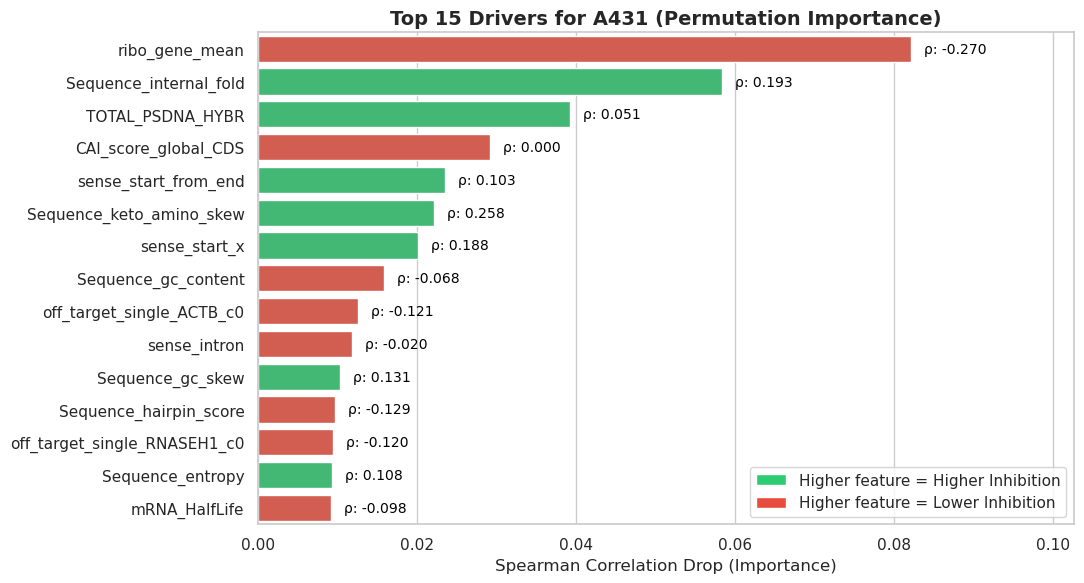

/tmp/ipykernel_1398676/95755575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)


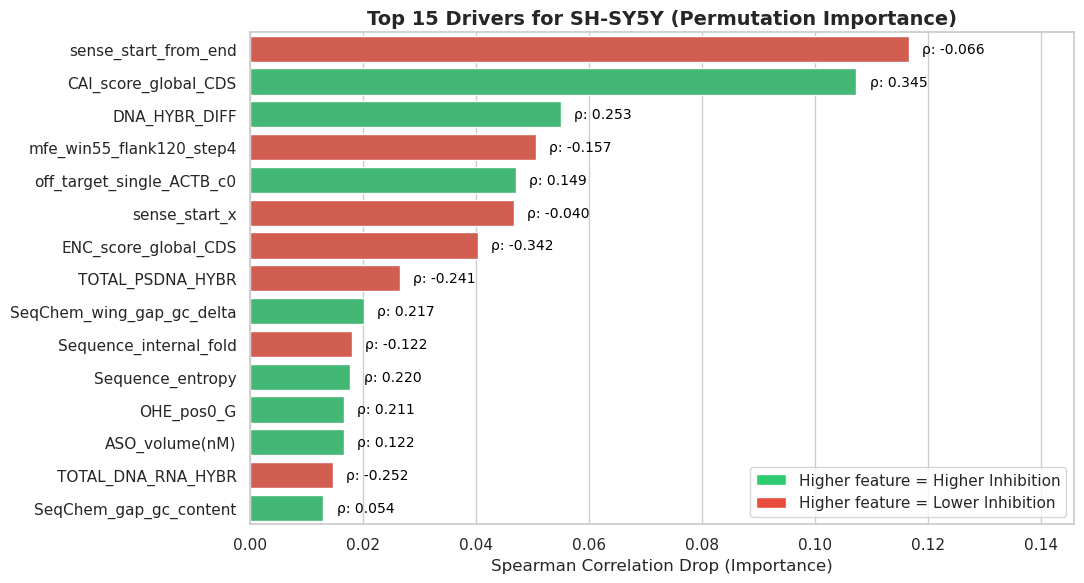

/tmp/ipykernel_1398676/95755575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)


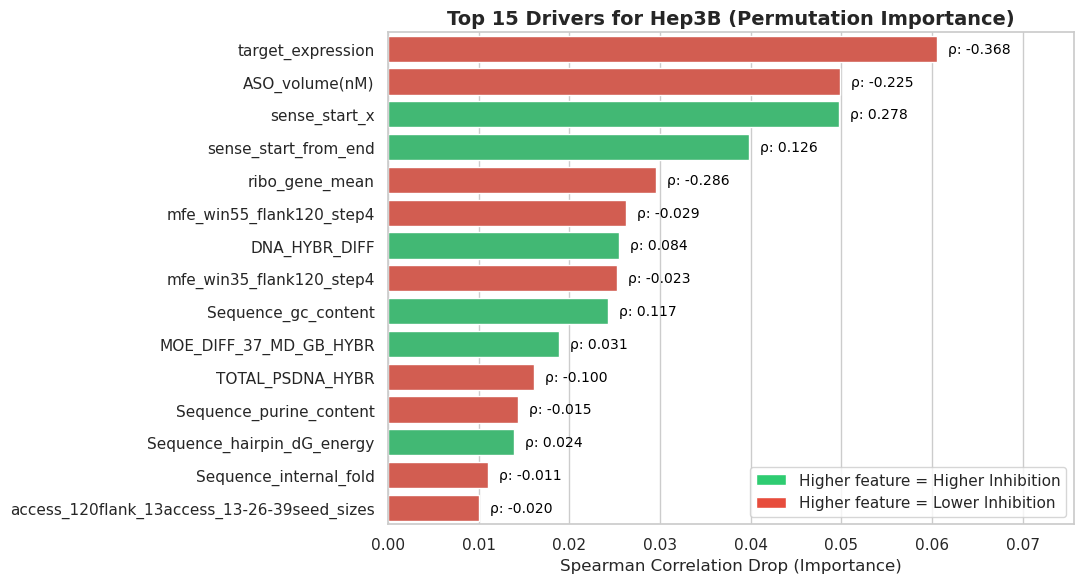

/tmp/ipykernel_1398676/95755575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)


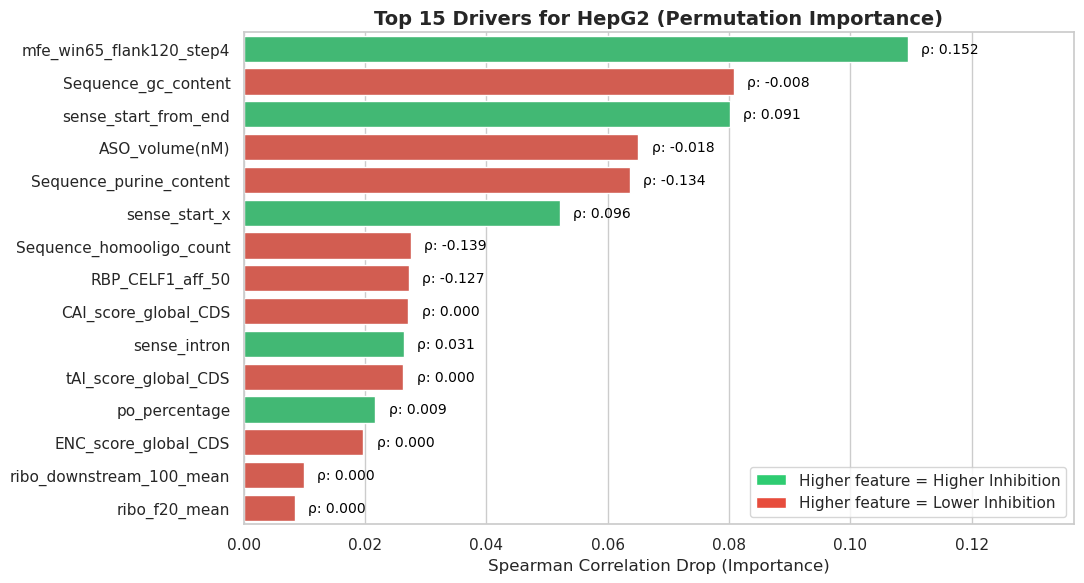

/tmp/ipykernel_1398676/95755575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)


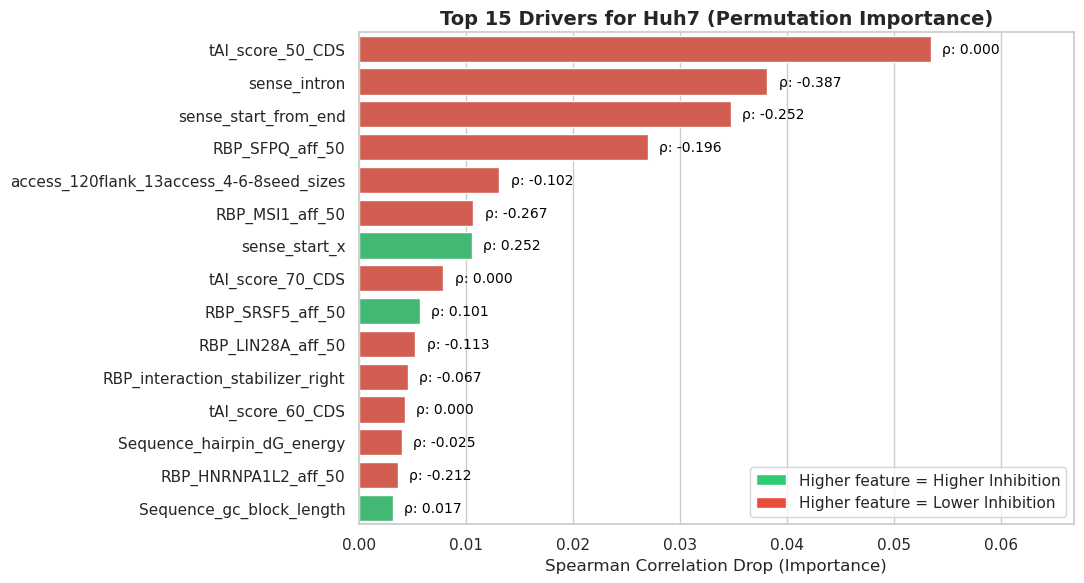

/tmp/ipykernel_1398676/95755575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)


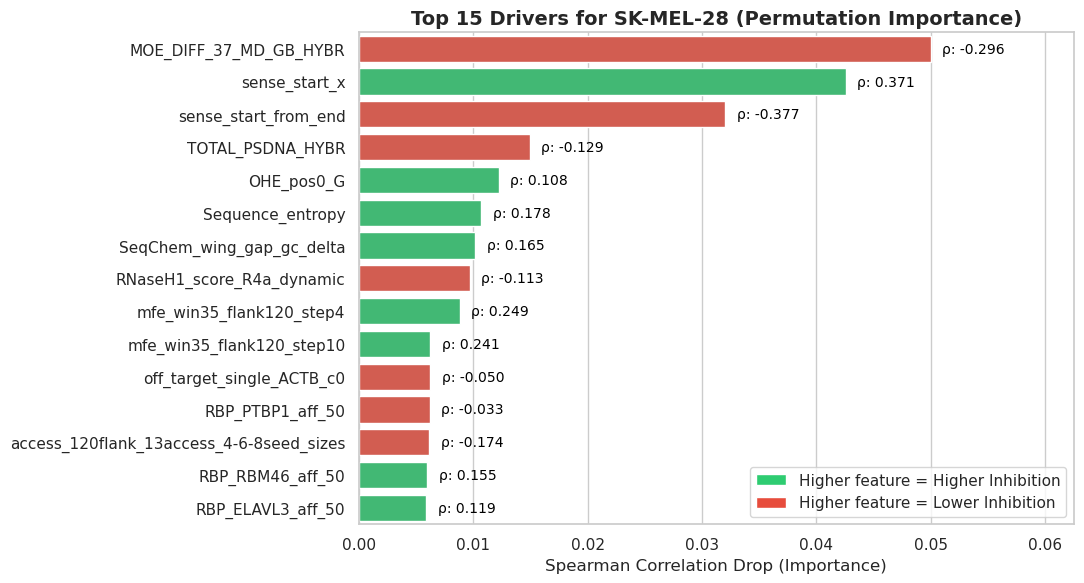

/tmp/ipykernel_1398676/95755575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)


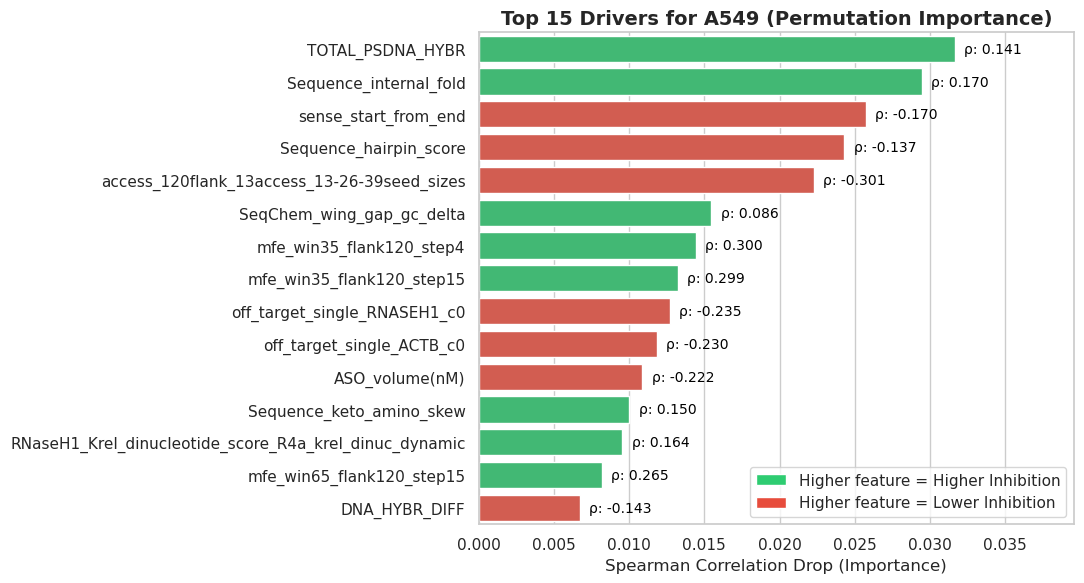

/tmp/ipykernel_1398676/95755575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)


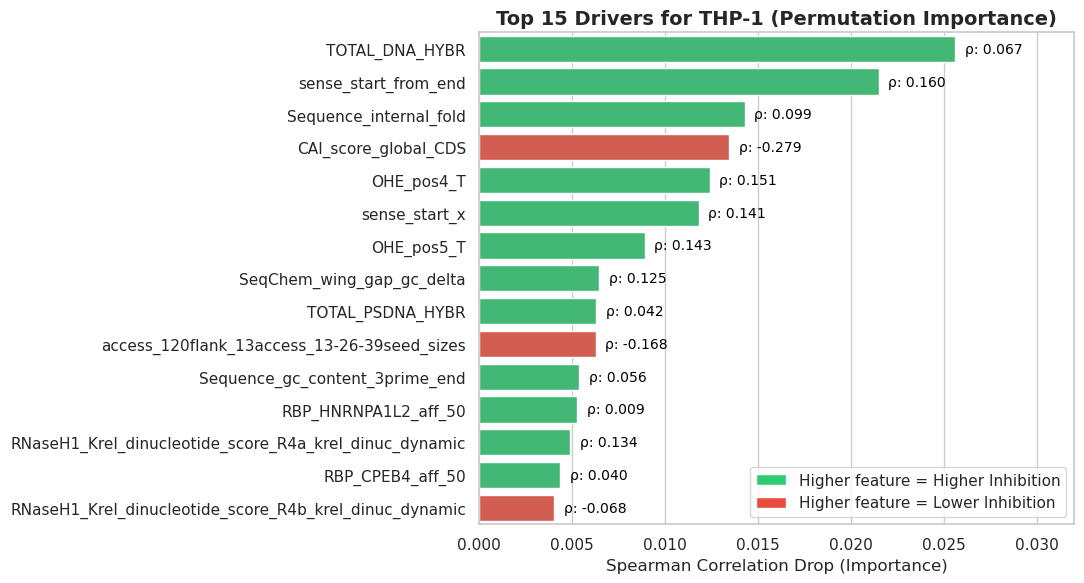

/tmp/ipykernel_1398676/95755575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)


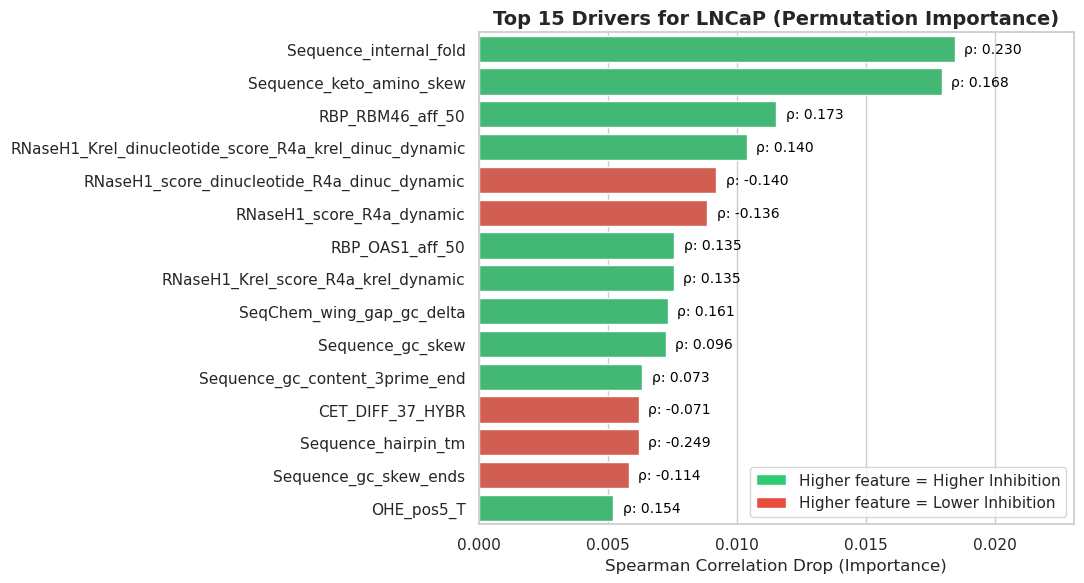

/tmp/ipykernel_1398676/95755575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)


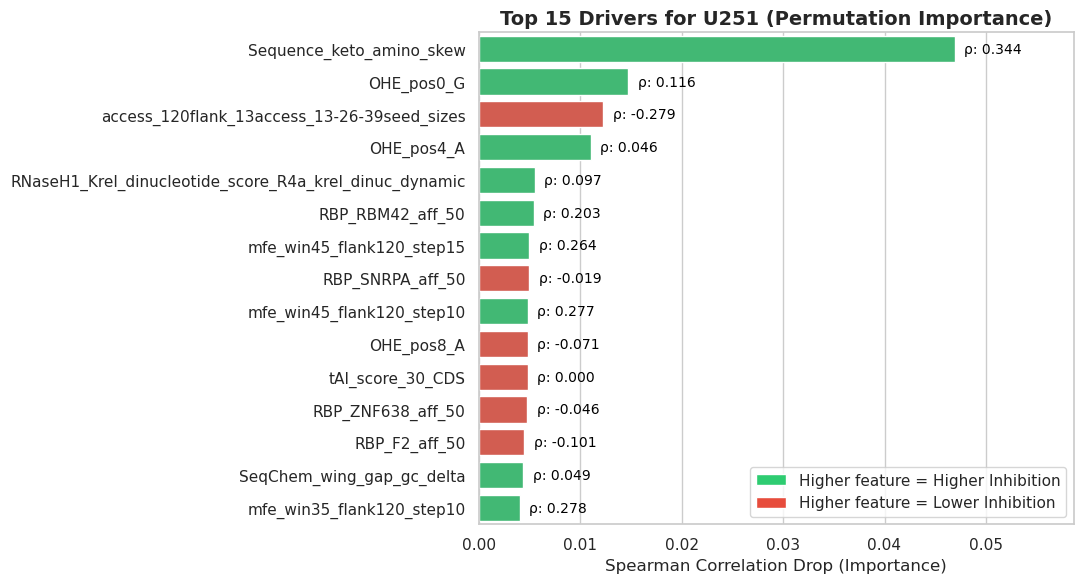

/tmp/ipykernel_1398676/95755575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)


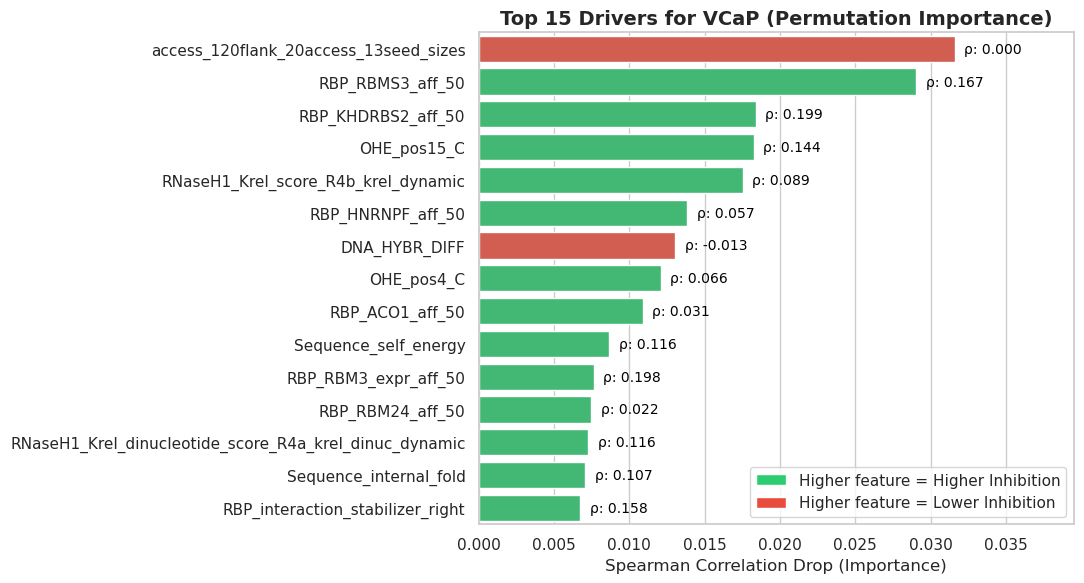

/tmp/ipykernel_1398676/95755575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)


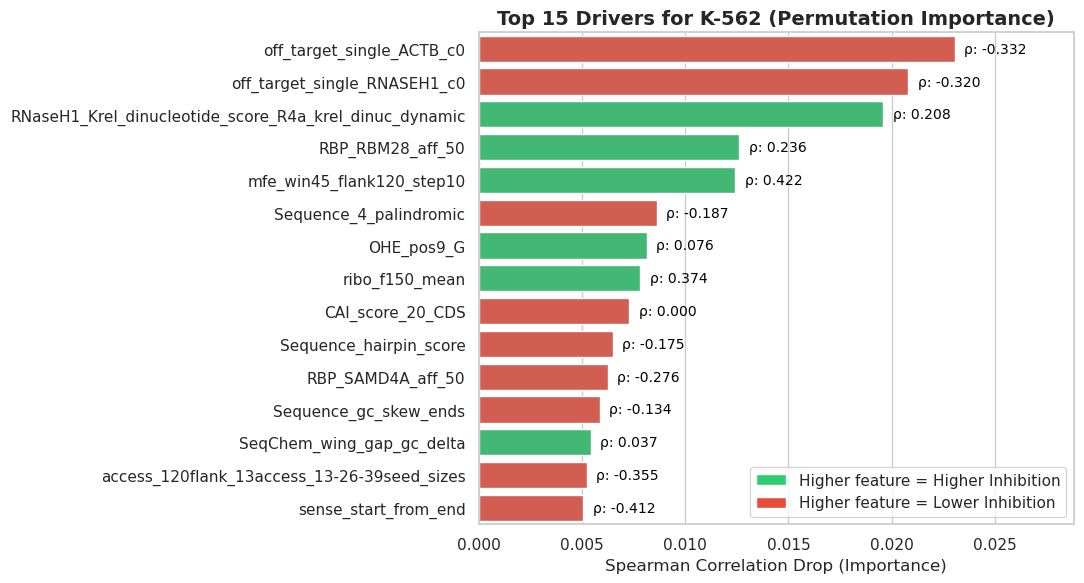

/tmp/ipykernel_1398676/95755575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)


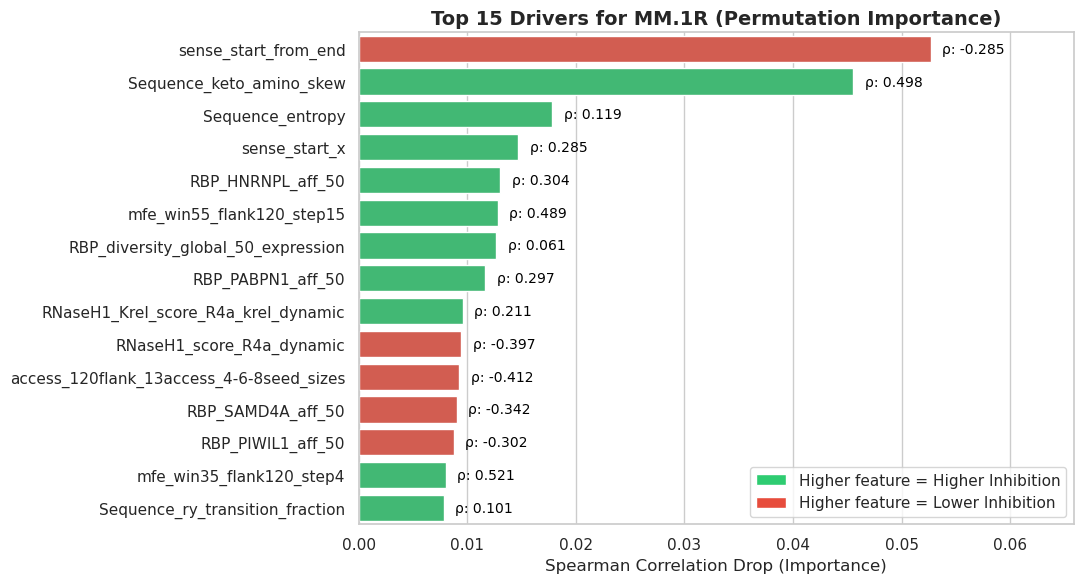

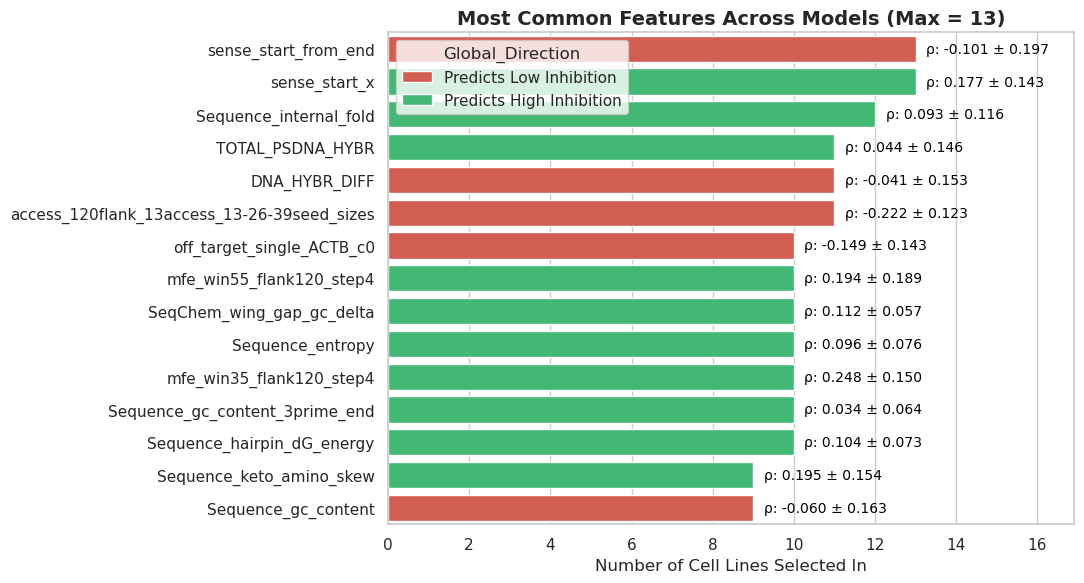

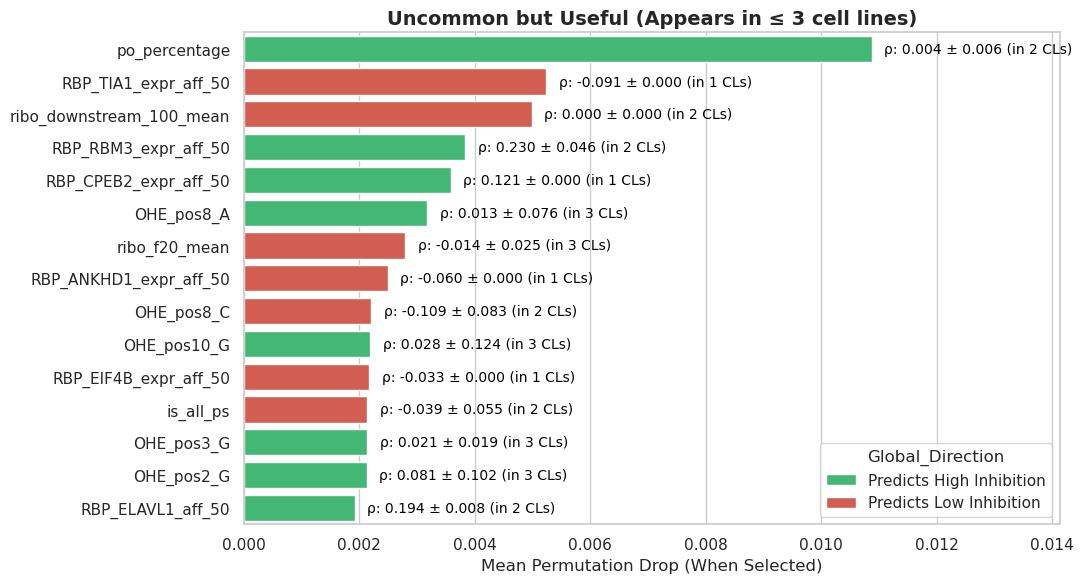

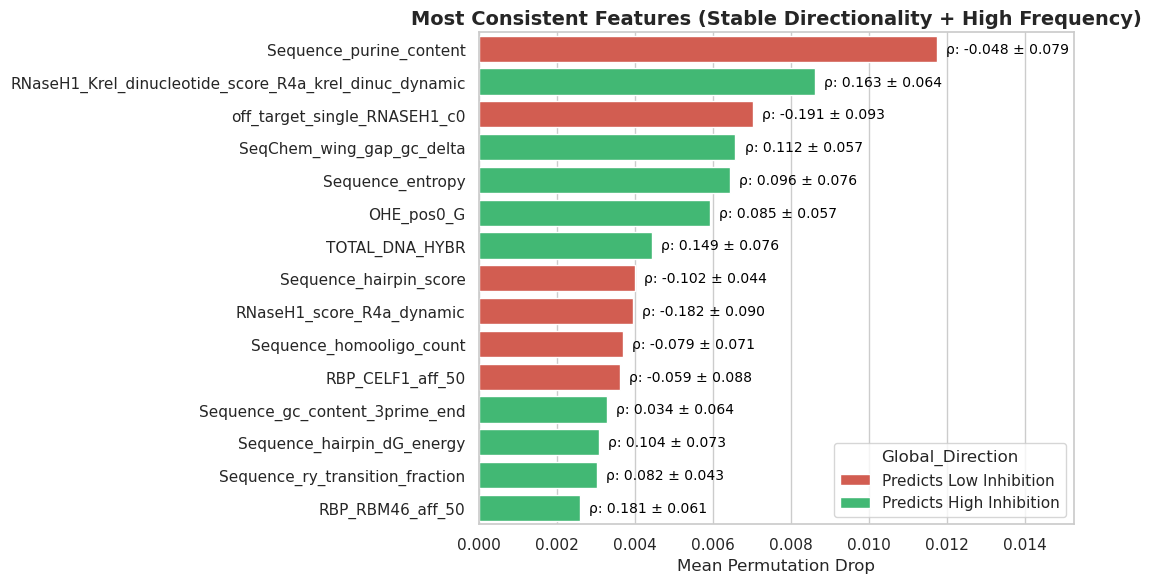

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Block 2: Plotting and Meta-Analysis across all cohorts
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")

# Custom color palette for directionality
# Green = Feature presence enhances knockdown | Red = Feature presence suppresses knockdown
dir_colors = {'Predicts High Inhibition': '#2ecc71', 'Predicts Low Inhibition': '#e74c3c'}
legend_elements = [
    Patch(facecolor='#2ecc71', label='Higher feature = Higher Inhibition'),
    Patch(facecolor='#e74c3c', label='Higher feature = Lower Inhibition')
]

# 1. Plot Individual Cell Line Feature Graphs (Separate Plots)
for cl in valid_cell_lines:
    df_cl = all_feature_stats[cl].head(15).copy()  # Top 15 for visual clarity

    plt.figure(figsize=(11, 6))
    palette = [dir_colors[d] for d in df_cl['Direction']]

    ax = sns.barplot(x='Permutation_Drop', y='Feature', data=df_cl, palette=palette)

    # Expand x-axis slightly to make room for text annotations
    max_x = df_cl['Permutation_Drop'].max()
    ax.set_xlim(0, max_x * 1.25)

    # Add magnitude text to the end of each bar
    for i, row in enumerate(df_cl.itertuples()):
        ax.text(row.Permutation_Drop + (max_x * 0.02), i,
                f"ρ: {row.Spearman_vs_Target:.3f}",
                va='center', color='black', fontsize=10, fontweight='500')

    plt.title(f"Top 15 Drivers for {cl} (Permutation Importance)", fontsize=14, fontweight='bold')
    plt.xlabel("Spearman Correlation Drop (Importance)")
    plt.ylabel("")
    plt.legend(handles=legend_elements, loc='lower right')
    plt.tight_layout()
    plt.show()

# --- META-ANALYSIS DATA PREP ---
df_all = pd.concat(all_feature_stats.values(), ignore_index=True)

meta_stats = df_all.groupby('Feature').agg(
    Appearance_Count=('Cell_Line', 'nunique'),
    Mean_Perm_Drop=('Permutation_Drop', 'mean'),
    Mean_XGB_Gain=('XGB_Gain', 'mean'),
    Mean_Correlation=('Spearman_vs_Target', 'mean'),
    Std_Correlation=('Spearman_vs_Target', 'std')  # High std means it acts differently across cell lines
).reset_index()

meta_stats['Std_Correlation'] = meta_stats['Std_Correlation'].fillna(0)
meta_stats['Global_Direction'] = np.where(meta_stats['Mean_Correlation'] > 0, 'Predicts High Inhibition',
                                          'Predicts Low Inhibition')

total_cl = len(valid_cell_lines)

# 2. Most Common Features Plot
common_feats = meta_stats.sort_values(by=['Appearance_Count', 'Mean_Perm_Drop'], ascending=[False, False]).head(15)
plt.figure(figsize=(11, 6))
ax = sns.barplot(x='Appearance_Count', y='Feature', data=common_feats, hue='Global_Direction', dodge=False,
                 palette=dir_colors)

max_x_common = common_feats['Appearance_Count'].max()
ax.set_xlim(0, max_x_common * 1.3)

for i, row in enumerate(common_feats.itertuples()):
    ax.text(row.Appearance_Count + (max_x_common * 0.02), i,
            f"ρ: {row.Mean_Correlation:.3f} ± {row.Std_Correlation:.3f}",
            va='center', color='black', fontsize=10, fontweight='500')

plt.title(f"Most Common Features Across Models (Max = {total_cl})", fontsize=14, fontweight='bold')
plt.xlabel("Number of Cell Lines Selected In")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 3. Uncommon but Highly Impactful Features
threshold = max(1, int(total_cl * 0.3))
uncommon_feats = meta_stats[meta_stats['Appearance_Count'] <= threshold].sort_values(by='Mean_Perm_Drop',
                                                                                     ascending=False).head(15)

if not uncommon_feats.empty:
    plt.figure(figsize=(11, 6))
    ax = sns.barplot(x='Mean_Perm_Drop', y='Feature', data=uncommon_feats, hue='Global_Direction', dodge=False,
                     palette=dir_colors)

    max_x_uncommon = uncommon_feats['Mean_Perm_Drop'].max()
    ax.set_xlim(0, max_x_uncommon * 1.3)

    for i, row in enumerate(uncommon_feats.itertuples()):
        ax.text(row.Mean_Perm_Drop + (max_x_uncommon * 0.02), i,
                f"ρ: {row.Mean_Correlation:.3f} ± {row.Std_Correlation:.3f} (in {row.Appearance_Count} CLs)",
                va='center', color='black', fontsize=10, fontweight='500')

    plt.title(f"Uncommon but Useful (Appears in ≤ {threshold} cell lines)", fontsize=14, fontweight='bold')
    plt.xlabel("Mean Permutation Drop (When Selected)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

# 4. Most Consistent Features Plot
consistent_feats = meta_stats[(meta_stats['Appearance_Count'] >= total_cl * 0.5) &
                              (meta_stats['Std_Correlation'] < 0.1)].sort_values(by='Mean_Perm_Drop',
                                                                                 ascending=False).head(15)

if not consistent_feats.empty:
    plt.figure(figsize=(11, 6))
    ax = sns.barplot(x='Mean_Perm_Drop', y='Feature', data=consistent_feats, hue='Global_Direction', dodge=False,
                     palette=dir_colors)

    max_x_consistent = consistent_feats['Mean_Perm_Drop'].max()
    ax.set_xlim(0, max_x_consistent * 1.3)

    for i, row in enumerate(consistent_feats.itertuples()):
        ax.text(row.Mean_Perm_Drop + (max_x_consistent * 0.02), i,
                f"ρ: {row.Mean_Correlation:.3f} ± {row.Std_Correlation:.3f}",
                va='center', color='black', fontsize=10, fontweight='500')

    plt.title("Most Consistent Features (Stable Directionality + High Frequency)", fontsize=14, fontweight='bold')
    plt.xlabel("Mean Permutation Drop")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()